In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
df = pd.read_csv('personality_dataset.csv')

In [3]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [5]:
df['Personality'].value_counts()

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

C:\Users\Ali Mansoori\AppData\Local\Temp\ipykernel_12632\3692288490.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Personality",data=df,palette="pastel")


<Axes: xlabel='Personality', ylabel='count'>

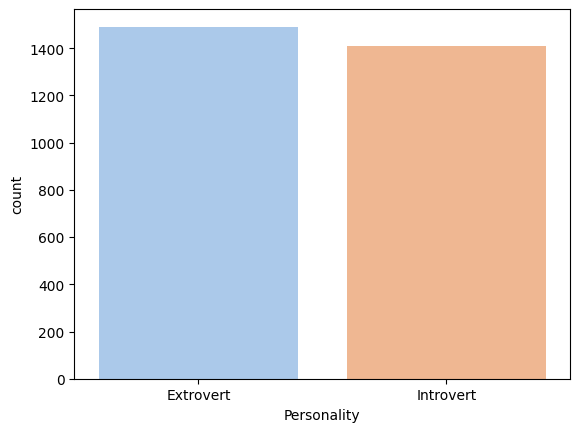

In [6]:
plt.Figure(figsize=(6,4))
sns.countplot(x="Personality",data=df,palette="pastel")

In [7]:
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype=="object":
        df[col]=le.fit_transform(df[col])

In [8]:
df.isna().sum()

Time_spent_Alone             63
Stage_fear                    0
Social_event_attendance      62
Going_outside                66
Drained_after_socializing     0
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

In [9]:
columns=['Time_spent_Alone','Stage_fear','Social_event_attendance','Going_outside','Drained_after_socializing','Friends_circle_size','Post_frequency']
for col in columns:
    df[col]=df[col].fillna(df[col].median())

In [10]:
df.describe()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.494828,0.536552,3.942759,3.000000,0.521034,6.235172,3.552069,0.485862
std,3.441971,0.546911,2.875987,2.221597,0.534339,4.237255,2.894794,0.499886
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,2.000000,1.000000,0.000000,3.000000,1.000000,0.000000
50%,4.000000,1.000000,3.000000,3.000000,1.000000,5.000000,3.000000,0.000000
75%,7.000000,1.000000,6.000000,5.000000,1.000000,10.000000,6.000000,1.000000
max,11.000000,2.000000,10.000000,7.000000,2.000000,15.000000,10.000000,1.000000


In [11]:
x=df.drop("Personality",axis=1)
y=df['Personality']

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
models=[LogisticRegression(),DecisionTreeClassifier()]

for model in models:
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(accuracy_score(y_test,y_pred)*100)

92.06896551724138
87.24137931034483


In [14]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88       302
           1       0.86      0.88      0.87       278

    accuracy                           0.87       580
   macro avg       0.87      0.87      0.87       580
weighted avg       0.87      0.87      0.87       580



In [15]:
print(confusion_matrix(y_test,y_pred))

[[261  41]
 [ 33 245]]


In [16]:
x_train.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
2078,3.0,0,5.0,6.0,0,10.0,9.0
163,6.0,1,3.0,3.0,1,1.0,0.0
1938,10.0,1,2.0,2.0,1,1.0,0.0
252,9.0,1,1.0,2.0,1,3.0,1.0
2232,10.0,1,0.0,0.0,1,4.0,1.0


In [17]:
test=[[1,1,3,2,0,1,0]]

pred=model.predict(test)
print(pred)

[0]


C:\Users\Ali Mansoori\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
